In [1]:
import os

# Asegurar que exista la carpeta data (un nivel arriba de notebooks/)
os.makedirs("../data", exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficas
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [2]:
# Obtener credenciales del entorno
DB_HOST = os.getenv('DB_HOST', 'localhost')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_USER = os.getenv('DB_USER', 'postgres')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_NAME = os.getenv('DB_NAME', 'superheroes_etl')

# Construir URL de conexión
DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

# Crear engine
engine = create_engine(DATABASE_URL)

# Probar conexión
try:
    with engine.connect() as conn:
        print("✅ Conexión a PostgreSQL exitosa")
except Exception as e:
    print(f"❌ Error de conexión: {str(e)}")

✅ Conexión a PostgreSQL exitosa


In [3]:
# ===============================
# Celda 3: Cargar datos desde PostgreSQL
# ===============================

query = """
SELECT
    s.nombre AS superheroe,
    s.editorial,
    p.inteligencia,
    p.fuerza,
    p.velocidad,
    p.durabilidad,
    p.poder,
    p.combate,
    p.fecha_extraccion
FROM powerstats p
JOIN superheroes s ON p.superhero_id = s.id
WHERE p.inteligencia IS NOT NULL
  AND p.fuerza IS NOT NULL
  AND p.poder IS NOT NULL
ORDER BY p.fecha_extraccion DESC
"""

# Cargar datos en DataFrame
df = pd.read_sql(query, engine)

print(f"📊 Datos cargados: {len(df)} registros")
print("\n📄 Información del Dataset:")
print(df.info())

print("\n🔍 Primeros registros:")
df.head(10)

📊 Datos cargados: 581 registros

📄 Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581 entries, 0 to 580
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   superheroe        581 non-null    object        
 1   editorial         581 non-null    object        
 2   inteligencia      581 non-null    int64         
 3   fuerza            581 non-null    int64         
 4   velocidad         581 non-null    int64         
 5   durabilidad       581 non-null    int64         
 6   poder             581 non-null    int64         
 7   combate           581 non-null    int64         
 8   fecha_extraccion  581 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(6), object(2)
memory usage: 41.0+ KB
None

🔍 Primeros registros:


,superheroe,editorial,inteligencia,fuerza,velocidad,durabilidad,poder,combate,fecha_extraccion
0,T-1000,Dark Horse Comics,75,34,33,100,100,75,2026-04-05 02:50:43.114822
1,T-850,Dark Horse Comics,75,80,25,90,83,75,2026-04-05 02:50:04.928769
2,T-800,Dark Horse Comics,75,34,17,60,73,65,2026-04-05 02:48:03.538335
3,X-23,Marvel Comics,75,24,42,100,55,95,2026-04-05 02:45:26.823072
4,Kevin 11,DC Comics,25,7,12,14,100,40,2026-04-05 02:45:14.530048
5,Ben 10,DC Comics,10,7,8,10,90,40,2026-04-05 02:45:11.369505
6,Enchantress,DC Comics,63,14,25,60,100,40,2026-04-04 22:10:55.441443
7,Emma Frost,Marvel Comics,75,63,35,90,100,42,2026-04-04 22:10:54.279421
8,Elongated Man,DC Comics,75,10,33,90,44,40,2026-04-04 22:10:51.562142
9,Elle Bishop,NBC - Heroes,50,8,12,42,63,42,2026-04-04 22:10:48.772132


📈 Estadísticas Descriptivas:
       inteligencia      fuerza   velocidad  durabilidad       poder  \
count    581.000000  581.000000  581.000000   581.000000  581.000000   
mean      62.425129   53.282272   51.941480    59.461274   61.302926   
std       22.454475   27.464702   25.145919    26.106822   24.591374   
min        8.000000    7.000000    8.000000     5.000000    5.000000   
25%       46.000000   30.000000   32.000000    35.000000   42.000000   
50%       63.000000   53.000000   47.000000    59.000000   61.000000   
75%       81.000000   79.000000   74.000000    84.000000   81.000000   
max      100.000000  100.000000  100.000000   100.000000  100.000000   

          combate  
count  581.000000  
mean    60.877797  
std     22.884580  
min     10.000000  
25%     41.000000  
50%     61.000000  
75%     80.000000  
max    101.000000  

🔗 Matriz de Correlación:
              inteligencia    fuerza  velocidad  durabilidad     poder  \
inteligencia      1.000000  0.108103   0.0

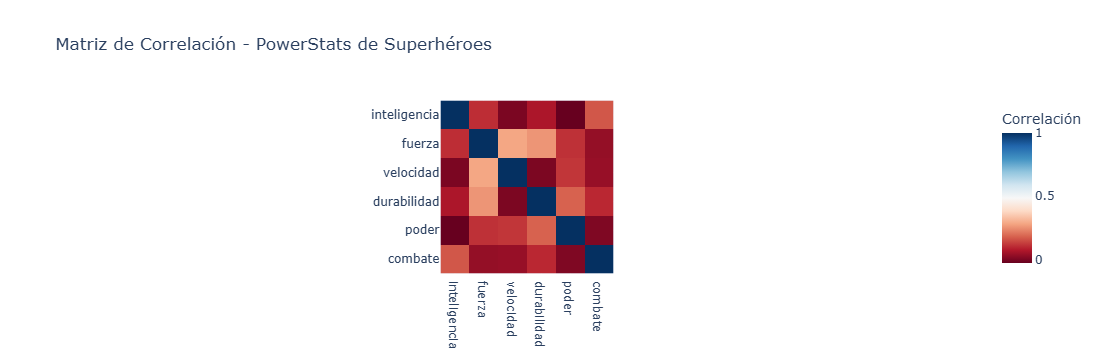

✅ Gráfica guardada: data/matriz_correlacion_powerstats.png


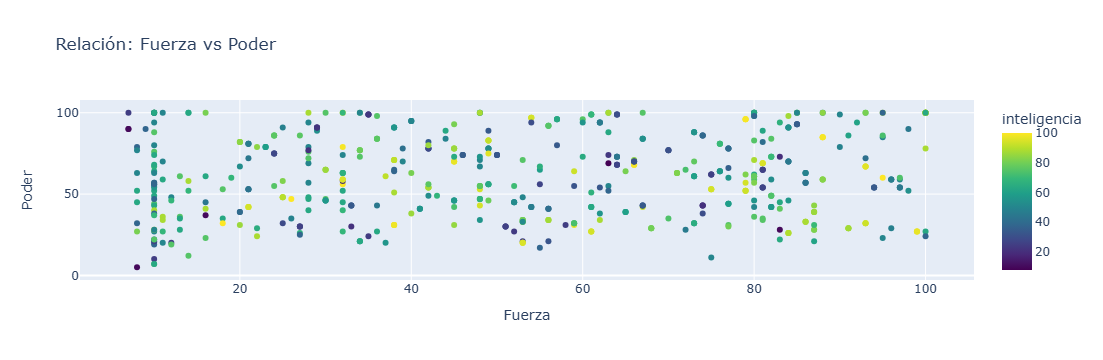

✅ Gráfica guardada: data/fuerza_vs_poder.png


In [7]:
# ===============================
# Celda 4: Análisis Exploratorio de Datos (EDA)
# ===============================

# ----------------------------------
# Estadísticas descriptivas
# ----------------------------------
print("📈 Estadísticas Descriptivas:")
print(
    df[['inteligencia', 'fuerza', 'velocidad', 'durabilidad', 'poder', 'combate']]
    .describe()
)

# ----------------------------------
# Matriz de correlación
# ----------------------------------
print("\n🔗 Matriz de Correlación:")
correlation = df[
    ['inteligencia', 'fuerza', 'velocidad', 'durabilidad', 'poder', 'combate']
].corr()
print(correlation)

# ----------------------------------
# Heatmap de correlación
# ----------------------------------
fig_corr = px.imshow(
    correlation,
    labels=dict(color="Correlación"),
    title="Matriz de Correlación - PowerStats de Superhéroes",
    color_continuous_scale="RdBu"
)

# ✅ Guardar imagen con Kaleido
fig_corr.write_image(
    "../data/matriz_correlacion_powerstats.png",
    width=1000,
    height=800
)

fig_corr.show()

print("✅ Gráfica guardada: data/matriz_correlacion_powerstats.png")

# ----------------------------------
# Scatter plot: Fuerza vs Poder
# ----------------------------------
fig_scatter = px.scatter(
    df,
    x='fuerza',
    y='poder',
    title='Relación: Fuerza vs Poder',
    labels={
        'fuerza': 'Fuerza',
        'poder': 'Poder'
    },
    color='inteligencia',
    color_continuous_scale='Viridis',
    hover_data=['superheroe', 'editorial']
)

# ✅ Guardar imagen con Kaleido
fig_scatter.write_image(
    "../data/fuerza_vs_poder.png",
    width=1000,
    height=800
)

fig_scatter.show()

print("✅ Gráfica guardada: data/fuerza_vs_poder.png")

In [8]:
# ===============================
# Celda 5: Preparar Datos para Regresión
# ===============================

# Variable independiente (X): Fuerza
X = df[['fuerza']].values

# Variable dependiente (y): Poder
y = df['poder'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# División de datos: 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\n📊 División de datos:")
print(f"  Entrenamiento: {len(X_train)} muestras ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Prueba: {len(X_test)} muestras ({len(X_test)/len(X)*100:.1f}%)")


X shape: (581, 1)
y shape: (581,)

📊 División de datos:
  Entrenamiento: 464 muestras (79.9%)
  Prueba: 117 muestras (20.1%)


In [12]:
# ===============================
# Celda 6: Entrenar Modelo de Regresión Lineal
# ===============================

# Crear instancia del modelo
model = LinearRegression()

# Entrenar el modelo
model.fit(X_train, y_train)

print("✅ Modelo entrenado correctamente")

# Coeficientes del modelo
intercepto = model.intercept_
coef_fuerza = model.coef_[0]

print("\n📐 Coeficientes del Modelo:")
print(f"  Intercepto (β₀): {intercepto:.4f}")
print(f"  Coeficiente Fuerza (β₁): {coef_fuerza:.4f}")

# Interpretación del modelo
print("\n💡 Interpretación del Modelo:")
print(f"  Poder = {intercepto:.2f} + ({coef_fuerza:.4f} × Fuerza)")

if coef_fuerza > 0:
    print(
        f"  📈 Por cada punto adicional de fuerza, "
        f"el poder aumenta en promedio {coef_fuerza:.4f} unidades"
    )
else:
    print(
        f"  📉 Por cada punto adicional de fuerza, "
        f"el poder disminuye en promedio {abs(coef_fuerza):.4f} unidades"
    )

✅ Modelo entrenado correctamente

📐 Coeficientes del Modelo:
  Intercepto (β₀): 56.1839
  Coeficiente Fuerza (β₁): 0.1072

💡 Interpretación del Modelo:
  Poder = 56.18 + (0.1072 × Fuerza)
  📈 Por cada punto adicional de fuerza, el poder aumenta en promedio 0.1072 unidades


In [13]:
# ===============================
# Celda 7: Hacer Predicciones
# ===============================

# Predicciones en datos de entrenamiento
y_train_pred = model.predict(X_train)

# Predicciones en datos de prueba
y_test_pred = model.predict(X_test)

print("✅ Predicciones realizadas correctamente")

# Comparar primeras 10 predicciones del conjunto de prueba
print("\n🔍 Primeras 10 predicciones vs valores reales (conjunto de prueba):")

comparison = pd.DataFrame({
    'Fuerza': X_test[:10, 0],
    'Poder Real': y_test[:10],
    'Poder Predicho': y_test_pred[:10],
    'Error': y_test[:10] - y_test_pred[:10]
})

comparison

✅ Predicciones realizadas correctamente

🔍 Primeras 10 predicciones vs valores reales (conjunto de prueba):


,Fuerza,Poder Real,Poder Predicho,Error
0,77,30,64.435459,-34.435459
1,93,67,66.150077,0.849923
2,11,70,57.362658,12.637342
3,96,59,66.471568,-7.471568
4,57,80,62.292186,17.707814
5,30,65,59.398768,5.601232
6,27,30,59.077277,-29.077277
7,84,70,65.185604,4.814396
8,30,65,59.398768,5.601232
9,79,52,64.649786,-12.649786


In [14]:
# ===============================
# Celda 8: Calcular Métricas del Modelo
# ===============================

# Métricas en conjunto de entrenamiento
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Métricas en conjunto de prueba
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("=" * 65)
print("📊 MÉTRICAS DEL MODELO DE REGRESIÓN LINEAL (SUPERHÉROES)")
print("=" * 65)

print("\n🎯 CONJUNTO DE ENTRENAMIENTO:")
print(f"  MAE  (Error Absoluto Medio):        {train_mae:.4f} puntos de poder")
print(f"  MSE  (Error Cuadrático Medio):      {train_mse:.4f}")
print(f"  RMSE (Raíz del Error Cuadrático):   {train_rmse:.4f} puntos de poder")
print(f"  R²   (Coef. de Determinación):      {train_r2:.4f} ({train_r2*100:.2f}%)")

print("\n🧪 CONJUNTO DE PRUEBA:")
print(f"  MAE  (Error Absoluto Medio):        {test_mae:.4f} puntos de poder")
print(f"  MSE  (Error Cuadrático Medio):      {test_mse:.4f}")
print(f"  RMSE (Raíz del Error Cuadrático):   {test_rmse:.4f} puntos de poder")
print(f"  R²   (Coef. de Determinación):      {test_r2:.4f} ({test_r2*100:.2f}%)")

print("\n" + "=" * 65)

# Detección de overfitting
if abs(train_r2 - test_r2) > 0.1:
    print("⚠️ ALERTA: Posible overfitting (diferencia en R² > 0.1)")
else:
    print("✅ BUEN AJUSTE: El modelo generaliza adecuadamente")

📊 MÉTRICAS DEL MODELO DE REGRESIÓN LINEAL (SUPERHÉROES)

🎯 CONJUNTO DE ENTRENAMIENTO:
  MAE  (Error Absoluto Medio):        21.2759 puntos de poder
  MSE  (Error Cuadrático Medio):      610.2565
  RMSE (Raíz del Error Cuadrático):   24.7034 puntos de poder
  R²   (Coef. de Determinación):      0.0139 (1.39%)

🧪 CONJUNTO DE PRUEBA:
  MAE  (Error Absoluto Medio):        19.5173 puntos de poder
  MSE  (Error Cuadrático Medio):      541.1288
  RMSE (Raíz del Error Cuadrático):   23.2622 puntos de poder
  R²   (Coef. de Determinación):      -0.0071 (-0.71%)

✅ BUEN AJUSTE: El modelo generaliza adecuadamente


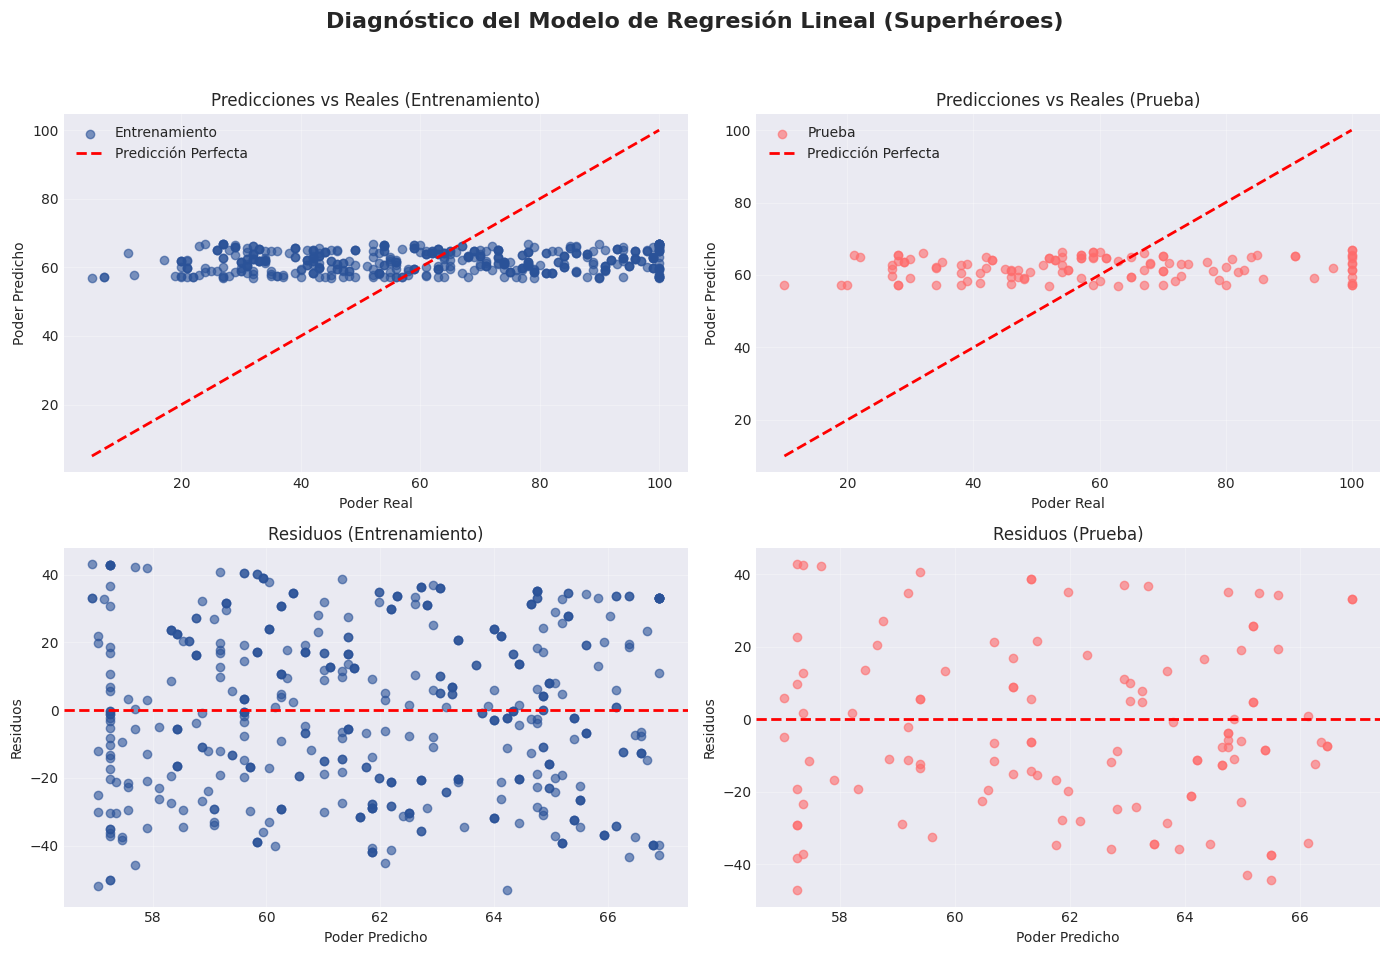

✅ Gráficas guardadas en data/diagnosticos_modelo_regresion_superheroes.png


In [15]:
# ===============================
# Celda 9: Visualizar Resultados del Modelo
# ===============================

import os
os.makedirs("../data", exist_ok=True)

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Diagnóstico del Modelo de Regresión Lineal (Superhéroes)',
    fontsize=16,
    fontweight='bold'
)

# -------------------------------------------------
# Gráfica 1: Valores Predichos vs Reales (Entrenamiento)
# -------------------------------------------------
axes[0, 0].scatter(
    y_train,
    y_train_pred,
    alpha=0.6,
    color='#2a5298',
    label='Entrenamiento'
)
axes[0, 0].plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    'r--',
    lw=2,
    label='Predicción Perfecta'
)
axes[0, 0].set_xlabel('Poder Real')
axes[0, 0].set_ylabel('Poder Predicho')
axes[0, 0].set_title('Predicciones vs Reales (Entrenamiento)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# -------------------------------------------------
# Gráfica 2: Valores Predichos vs Reales (Prueba)
# -------------------------------------------------
axes[0, 1].scatter(
    y_test,
    y_test_pred,
    alpha=0.6,
    color='#ff6b6b',
    label='Prueba'
)
axes[0, 1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2,
    label='Predicción Perfecta'
)
axes[0, 1].set_xlabel('Poder Real')
axes[0, 1].set_ylabel('Poder Predicho')
axes[0, 1].set_title('Predicciones vs Reales (Prueba)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# -------------------------------------------------
# Gráfica 3: Residuos (Entrenamiento)
# -------------------------------------------------
residuals_train = y_train - y_train_pred
axes[1, 0].scatter(
    y_train_pred,
    residuals_train,
    alpha=0.6,
    color='#2a5298'
)
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Poder Predicho')
axes[1, 0].set_ylabel('Residuos')
axes[1, 0].set_title('Residuos (Entrenamiento)')
axes[1, 0].grid(alpha=0.3)

# -------------------------------------------------
# Gráfica 4: Residuos (Prueba)
# -------------------------------------------------
residuals_test = y_test - y_test_pred
axes[1, 1].scatter(
    y_test_pred,
    residuals_test,
    alpha=0.6,
    color='#ff6b6b'
)
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Poder Predicho')
axes[1, 1].set_ylabel('Residuos')
axes[1, 1].set_title('Residuos (Prueba)')
axes[1, 1].grid(alpha=0.3)

# Ajuste y guardado
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(
    "../data/diagnosticos_modelo_regresion_superheroes.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print("✅ Gráficas guardadas en data/diagnosticos_modelo_regresion_superheroes.png")